# Nu-Classifier Model Analysis

Loads predictions from `predict_mc.py` and `predict_exp.py` and produces:
1. Score distribution histograms (muatm / nuatm / nue2 / exp)
2. Suppression vs efficiency curve
3. UMAP of encoder representations (sampled, encoded on-the-fly)
4. Matching utility: enrich MC predictions with truth info from source h5

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

MODEL_TAG = "260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32"
#MODEL_TAG = "260507_2121_da_nu_classifier_h5s0_lambda0.01_thr0.8"

# ── Paths — edit these ────────────────────────────────────────────────
MC_PREDS_H5  = PROJECT_ROOT / f"inference/nu_classifier_model/results/mc_preds_{MODEL_TAG}.h5"
EXP_PREDS_H5 = PROJECT_ROOT / f"inference/nu_classifier_model/results/exp_preds_{MODEL_TAG}.h5"
EXP_KEY = "exp" #"exp_reco"
CHECKPOINT   = PROJECT_ROOT / f"experiments/numu/{MODEL_TAG}/best_da_model.pth"

MC_H5    = PROJECT_ROOT / "data_manager/data/h5datasets/baikal_mc_merged.h5"
#EXP_H5   = PROJECT_ROOT / "data_manager/data/h5datasets/exp_reco.h5"
EXP_H5   = PROJECT_ROOT / "data_manager/data/h5datasets/exp.h5"
PROBS_H5 = PROJECT_ROOT / "data_manager/data/h5datasets/baikal_mc_merged_probs_k_nsol_labelneq0_da_hs128_k0p0001.h5"

THRESHOLD = 0.8   # sig-noise threshold used during inference

PTYPE_COLORS = {
    "muatm_2020": "steelblue",
    "nuatm_2020": "forestgreen",
    "nue2_2020":  "darkorange",
    "exp_reco":   "crimson",
    "exp_reco_strange": "purple"
}
PTYPE_LABELS = {
    "muatm_2020": r"MC EAS",
    "nuatm_2020": r"MC $\nu_\mu^{atmospheric}$",
    "nue2_2020":  r"MC $\nu_\mu^{cosmogenic}$",
    "exp_reco":   "EXP",
    "exp_reco_strange": "EXP big score"
}

RC = {
    "font.size":        14,
    "axes.labelsize":   16,
    "axes.titlesize":   16,
    "legend.fontsize":  13,
    "xtick.labelsize":  13,
    "ytick.labelsize":  13,
    "figure.dpi":       120,
}

## Cell 1 — Loader functions

In [2]:
def load_baikal_mc_merged_scores(h5_path: str | Path) -> pd.DataFrame:
    """Load MC predictions from /baikal_mc_merged/{ptype}/... groups.

    Returns DataFrame with columns:
        ptype, part_key, event_id, score, n_sig_hits, n_sig_strings
    """
    chunks = []
    with h5py.File(h5_path, "r") as f:
        mc_grp = f["baikal_mc_merged"]
        for ptype in mc_grp.keys():
            if "scores" not in mc_grp[ptype]:
                continue
            for pk in tqdm(mc_grp[ptype]["scores"].keys(), desc=f'Loading {ptype} MC parts'):
                scores    = mc_grp[f"{ptype}/scores/{pk}/data"][:]
                n_sh      = mc_grp[f"{ptype}/n_sig_hits/{pk}/data"][:]
                n_ss      = mc_grp[f"{ptype}/n_sig_strings/{pk}/data"][:]
                event_ids = mc_grp[f"{ptype}/event_ids/{pk}/data"][:]
                chunks.append(pd.DataFrame({
                    "ptype":         ptype,
                    "part_key":      pk,
                    "event_id":      event_ids,
                    "score":         scores,
                    "n_sig_hits":    n_sh,
                    "n_sig_strings": n_ss,
                }))
    df = pd.concat(chunks, ignore_index=True)
    print(f"MC scores loaded: {len(df):,} events  "
          f"({df['ptype'].value_counts().to_dict()})")
    return df


def load_exp_scores(h5_path: str | Path, exp_key = EXP_KEY) -> pd.DataFrame:
    """Load exp predictions from /exp_reco/... groups.

    Returns DataFrame with columns:
        part_key, event_id, score, n_sig_hits, n_sig_strings
    """
    chunks = []
    with h5py.File(h5_path, "r") as f:
        if exp_key not in f:
            raise KeyError(f"Group '{exp_key}' not found in exp predictions h5")
        grp = f[exp_key]
        for pk in tqdm(grp["scores"].keys(), desc='Loading exp parts'):
            scores    = grp[f"scores/{pk}/data"][:]
            n_sh      = grp[f"n_sig_hits/{pk}/data"][:]
            n_ss      = grp[f"n_sig_strings/{pk}/data"][:]
            event_ids = grp[f"event_ids/{pk}/data"][:]
            chunks.append(pd.DataFrame({
                "part_key":      pk,
                "event_id":      event_ids,
                "score":         scores,
                "n_sig_hits":    n_sh,
                "n_sig_strings": n_ss,
            }))
    df = pd.concat(chunks, ignore_index=True)
    print(f"Exp scores loaded: {len(df):,} events")
    return df

In [3]:
def add_exp_max_q(df: pd.DataFrame, exp_h5_path: str | Path) -> pd.DataFrame:
    """Add 'max_q' column (max raw amplitude per event) from exp_reco.h5.

    Uses event_ids + part_key to look up hits in the source file.
    Operates on all raw hits (before sig-noise filtering).
    """
    from collections import defaultdict
    import numpy as np

    # Group row positions by part_key
    part_to_rows = defaultdict(list)  # pk -> [(row_pos, event_id), ...]
    for row_pos, (pk, eid) in enumerate(zip(df["part_key"], df["event_id"])):
        part_to_rows[pk].append((row_pos, int(eid)))

    max_q = np.empty(len(df), dtype=np.float32)

    with h5py.File(exp_h5_path, "r") as src:
        src_key = "exp_reco" if "exp_reco" in src else "exp"
        raw = src[src_key]["raw"]
        for pk, row_events in tqdm(part_to_rows.items(), desc='Adding max Q column'):
            data      = raw[f"data/{pk}/data"][:]          # (total_hits, 5)
            ev_starts = raw[f"ev_starts/{pk}/data"][:].astype(np.int64)
            for row_pos, eid in row_events:
                s, e = int(ev_starts[eid]), int(ev_starts[eid + 1])
                max_q[row_pos] = data[s:e, 0].max() if e > s else 0.0

    df = df.copy()
    df["max_q"] = max_q
    return df

In [4]:
with h5py.File(EXP_PREDS_H5, "r") as f:
    print(f.keys())

<KeysViewHDF5 ['exp', 'exp_reco']>


In [5]:
df_exp = load_exp_scores(EXP_PREDS_H5)
df_mc  = load_baikal_mc_merged_scores(MC_PREDS_H5)
# BAD_EXP_PARTS = [
#     'part_s2020_c04_r0118', 
#     'part_s2020_c02_r0206', 
#     'part_s2020_c05_r0391', 
#     'part_s2020_c05_r0392', 
#     'part_s2020_c05_r0100'
#     ]
# df_exp = df_exp[~(df_exp['part_key'].str.contains('c01'))]

df_exp = df_exp[~df_exp['part_key'].isin(['part_s2020_c04_r0117'])]

# ## Filter events having max Q >1e4 ev
# df_exp = add_exp_max_q(df_exp, EXP_H5)
# df_exp = df_exp[df_exp['max_q'] <= 1e4]


# Quality Masks
print("Starting...")
EXP_MASK = (df_exp['n_sig_hits']>=8) & (df_exp['n_sig_strings']>=3)
print("Got EXP mask")
MC_MASK = (df_mc['n_sig_hits']>=8) & (df_mc['n_sig_strings']>=3)
print("Got MC mask...")

muatm_scores = df_mc.loc[MC_MASK & (df_mc["ptype"] == "muatm_2020"), "score"].values
nuatm_scores = df_mc.loc[MC_MASK & (df_mc["ptype"] == "nuatm_2020"), "score"].values
nue2_scores  = df_mc.loc[MC_MASK & (df_mc["ptype"] == "nue2_2020"),  "score"].values
nu_scores    = np.concatenate([nuatm_scores, nue2_scores])
exp_scores   = df_exp[EXP_MASK]["score"].values

print(f"muatm: {len(muatm_scores):,}  nuatm: {len(nuatm_scores):,}  "
     f"nue2: {len(nue2_scores):,}  exp: {len(exp_scores):,}")

Loading exp parts:   0%|          | 0/26 [00:00<?, ?it/s]

Exp scores loaded: 38,491 events


Loading muatm_2020 MC parts:   0%|          | 0/10000 [00:00<?, ?it/s]

Loading nuatm_2020 MC parts:   0%|          | 0/100 [00:00<?, ?it/s]

Loading nue2_2020 MC parts:   0%|          | 0/67 [00:00<?, ?it/s]

MC scores loaded: 76,560,464 events  ({'muatm_2020': 75083696, 'nue2_2020': 777539, 'nuatm_2020': 699229})
Starting...
Got EXP mask
Got MC mask...
muatm: 22,945,831  nuatm: 29,546  nue2: 323,817  exp: 15,449


In [10]:
# from inference.prefilter_model.utils import load_model as pref_load_model, predict_scores as pref_pred_scores

# PREF_MODEL_NAME = "da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
# #CHECKPOINT_PATH = "experiments/numu/da_prefilter_numu_260327_0127/best_da_model.pth"
# #CHECKPOINT_PATH = "experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth"
# PREF_CHECKPOINT_PATH = f"experiments/numu/{PREF_MODEL_NAME}/best_da_model.pth"

# model_pref, norm_config, train_config = pref_load_model(
#     str(PROJECT_ROOT / PREF_CHECKPOINT_PATH), device='cuda:2'
# )
# print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
# print(f"Model amp_clip: {model_pref.amp_clip:.4f} (normalized) "
#       f"= Q≈{model_pref.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")

# # Match exp events from exp_reco.h5 and load raw features (all hits, no sig-noise filtering)
# from collections import defaultdict

# part_to_rows = defaultdict(list)  # pk -> [(row_pos, event_id), ...]
# for row_pos, (pk, eid) in enumerate(zip(df_exp["part_key"], df_exp["event_id"])):
#     part_to_rows[pk].append((row_pos, int(eid)))

# raw_features = [None] * len(df_exp)

# with h5py.File(EXP_H5, "r") as src:
#     src_key = "exp_reco" if "exp_reco" in src else "exp"
#     raw = src[src_key]["raw"]
#     for pk, row_events in tqdm(part_to_rows.items(), desc="Loading raw exp hits"):
#         data_raw  = raw[f"data/{pk}/data"][:].astype(np.float32)
#         ev_starts = raw[f"ev_starts/{pk}/data"][:].astype(np.int64)
#         for row_pos, eid in row_events:
#             s, e = int(ev_starts[eid]), int(ev_starts[eid + 1])
#             raw_features[row_pos] = data_raw[s:e]

# # Predict scores by prefilter model and store to "pref_score" column in df_exp
# pref_scores = pref_pred_scores(
#     model_pref, raw_features, norm_config,
#     batch_size=512, device="cuda:2",
# )
# df_exp = df_exp.copy()
# df_exp["pref_score"] = pref_scores

# df_exp[(df_exp['score']>0.9) & (df_exp['pref_score']<0.8) & EXP_MASK]

## Cell 2 — Score distribution histograms

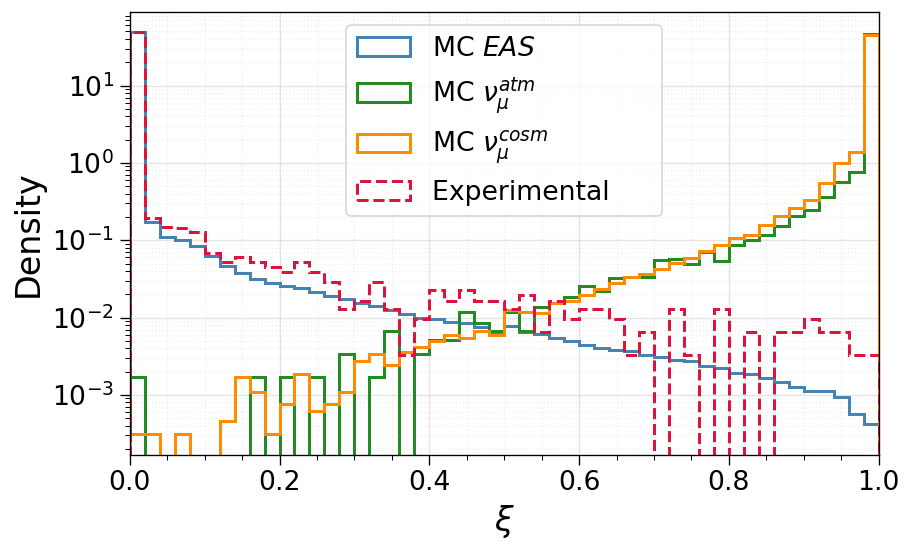

22,945,831
29,546
323,817
15,449


In [66]:
RC = {
    "font.size":        20,
    "axes.labelsize":   20,
    "axes.titlesize":   16,
    "legend.fontsize":  16,
    "xtick.labelsize":  16,
    "ytick.labelsize":  16,
    "figure.dpi":       120,
}

plt.close()
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(8, 5))

    bins = np.linspace(0, 1, 51)
    kw = dict(bins=bins, density=True, histtype="step", linewidth=1.8)

    text = r'EAS'
    ax.hist(muatm_scores, label=rf"MC ${text}$",
            color=PTYPE_COLORS["muatm_2020"], **kw)
    text = r'\nu_{\mu}^{atm}'
    ax.hist(nuatm_scores, label=fr"MC ${text}$",
            color=PTYPE_COLORS["nuatm_2020"], **kw)
    text = r'\nu_{\mu}^{cosm}'
    ax.hist(nue2_scores,  label=rf"MC ${text}$",
            color=PTYPE_COLORS["nue2_2020"],  **kw)
    ax.hist(exp_scores,   label=f"Experimental     ",
            color=PTYPE_COLORS["exp_reco"],   linestyle="--", **kw)

    ax.set_yscale("log")
    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel("Density")
    #ax.set_title("Nu-classifier score distributions")
    ax.legend()
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)
    ax.set_xlim(0,1)
    fig.tight_layout()
    plt.show()
fig.savefig(f'nu_classifier_score_distr_{MODEL_TAG}.png')
print(f"{len(muatm_scores):,}")
print(f"{len(nuatm_scores):,}")
print(f"{len(nue2_scores):,}")
print(f"{len(exp_scores):,}")

0.0002589164347206939


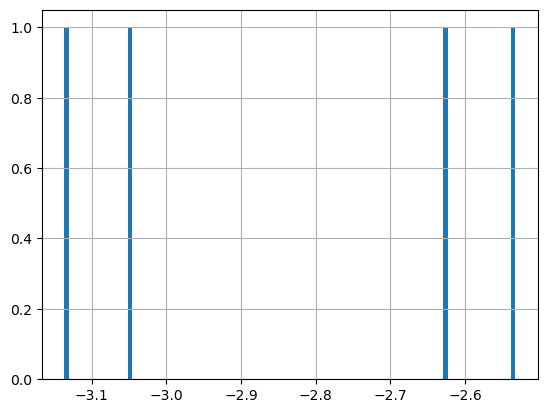

,count_cut,count_all,portion
part_key,,,
part_s2020_c05_r0377,1,341,0.002933
part_s2020_c03_r0417,1,423,0.002364
part_s2020_c04_r0116,1,1121,0.000892
part_s2020_c05_r0035,1,1370,0.000730


In [12]:
cut = 0.95

print((df_exp[EXP_MASK]['score']>cut).sum() / df_exp[EXP_MASK].__len__())

df_strange = df_exp[EXP_MASK][df_exp[EXP_MASK]['score']>cut]
df_counts_strange = pd.DataFrame(df_strange['part_key'].value_counts())
df_counts = pd.DataFrame(df_exp[EXP_MASK]['part_key'].value_counts())

df_counts_strange = df_counts_strange.merge(df_counts, on='part_key', how='left', suffixes=('_cut', '_all'))
df_counts_strange['portion'] = df_counts_strange['count_cut'] / df_counts_strange['count_all']

plt.close()
df_counts_strange['portion'].apply(np.log10).hist(bins=100)
plt.show()

display(df_counts_strange.sort_values('portion', ascending=False))

0.0002589164347206939


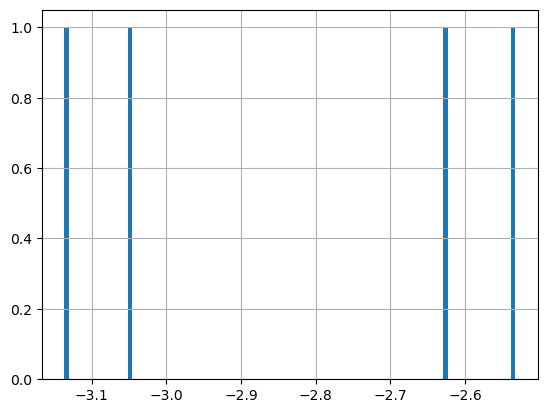

,count_cut,count_all,portion
part_key,,,
part_s2020_c05_r0377,1,341,0.002933
part_s2020_c03_r0417,1,423,0.002364
part_s2020_c04_r0116,1,1121,0.000892
part_s2020_c05_r0035,1,1370,0.000730


In [13]:
cut = 0.95

print((df_exp[EXP_MASK]['score']>cut).sum() / df_exp[EXP_MASK].__len__())

df_strange = df_exp[EXP_MASK][df_exp[EXP_MASK]['score']>cut]
df_counts_strange = pd.DataFrame(df_strange['part_key'].value_counts())
df_counts = pd.DataFrame(df_exp[EXP_MASK]['part_key'].value_counts())

df_counts_strange = df_counts_strange.merge(df_counts, on='part_key', how='left', suffixes=('_cut', '_all'))
df_counts_strange['portion'] = df_counts_strange['count_cut'] / df_counts_strange['count_all']

plt.close()
df_counts_strange['portion'].apply(np.log10).hist(bins=100)
plt.show()

display(df_counts_strange.sort_values('portion', ascending=False))

## Cell 3 — Suppression vs Efficiency

Working point: threshold=0.992  exp suppression≈1e+06  nu efficiency=0.713  muatm suppression=3.8e+06


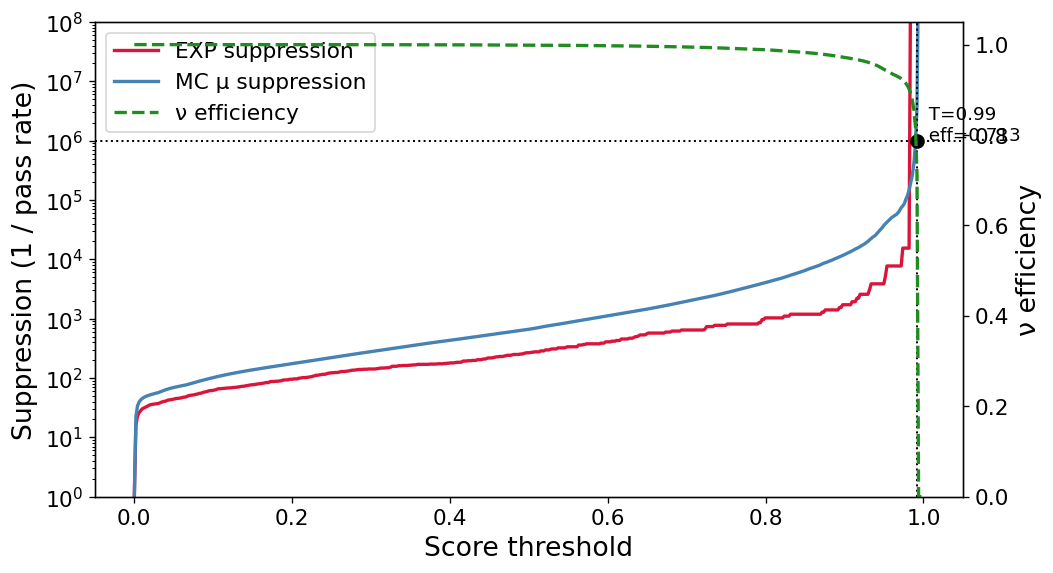

In [14]:
thresholds = np.linspace(0, 1, 500)

supp_muatm = np.array([1.0 / max((muatm_scores > t).mean(), 1e-9) for t in thresholds])
supp_exp   = np.array([1.0 / max((exp_scores   > t).mean(), 1e-9) for t in thresholds])
eff_nu     = np.array([(nu_scores > t).mean() for t in thresholds])

# Working point: 10^6 suppression of exp
TARGET_SUPP = 1e6
wp_idx = np.searchsorted(supp_muatm, TARGET_SUPP)
wp_thr = thresholds[min(wp_idx, len(thresholds) - 1)]
wp_eff = eff_nu[min(wp_idx, len(thresholds) - 1)]
wp_supp_mu = supp_muatm[min(wp_idx, len(thresholds) - 1)]
print(f"Working point: threshold={wp_thr:.3f}  "
      f"exp suppression≈{TARGET_SUPP:.0e}  "
      f"nu efficiency={wp_eff:.3f}  "
      f"muatm suppression={wp_supp_mu:.1e}")

plt.close()
with plt.rc_context(RC):
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    ax1.semilogy(thresholds, supp_exp,   color="crimson",    lw=2,   label="EXP suppression")
    ax1.semilogy(thresholds, supp_muatm, color="steelblue",  lw=2,   label="MC μ suppression")
    ax2.plot(    thresholds, eff_nu,     color="forestgreen", lw=2, ls="--", label="ν efficiency")

    # Working point marker
    ax1.axvline(wp_thr, color="k", ls=":", lw=1.2)
    ax1.axhline(TARGET_SUPP, color="k", ls=":", lw=1.2)
    ax1.scatter([wp_thr], [TARGET_SUPP], color="k", zorder=5, s=60)
    ax1.annotate(f"  T={wp_thr:.2f}\n  eff={wp_eff:.3f}",
                 (wp_thr, TARGET_SUPP), fontsize=11)

    ax1.set_xlabel("Score threshold")
    ax1.set_ylabel("Suppression (1 / pass rate)")
    ax2.set_ylabel("ν efficiency")
    ax1.set_ylim(1, 1e8)
    ax2.set_ylim(0, 1.05)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    fig.tight_layout()
    plt.show()

## Plot For the paper

In [6]:
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve

# ── Precompute arrays ──
df_mc["is_neutrino"] = df_mc["ptype"].str.startswith("nu")
SCORES     = df_mc["score"].values
SIG_HITS   = df_mc["n_sig_hits"].values
SIG_S      = df_mc["n_sig_strings"].values
IS_NU      = df_mc["is_neutrino"].values
IS_MU      = ~IS_NU
ptypes_arr = df_mc["ptype"].values

pos_nue2  = (ptypes_arr == "nue2_2020")
pos_nuatm = (ptypes_arr == "nuatm_2020")

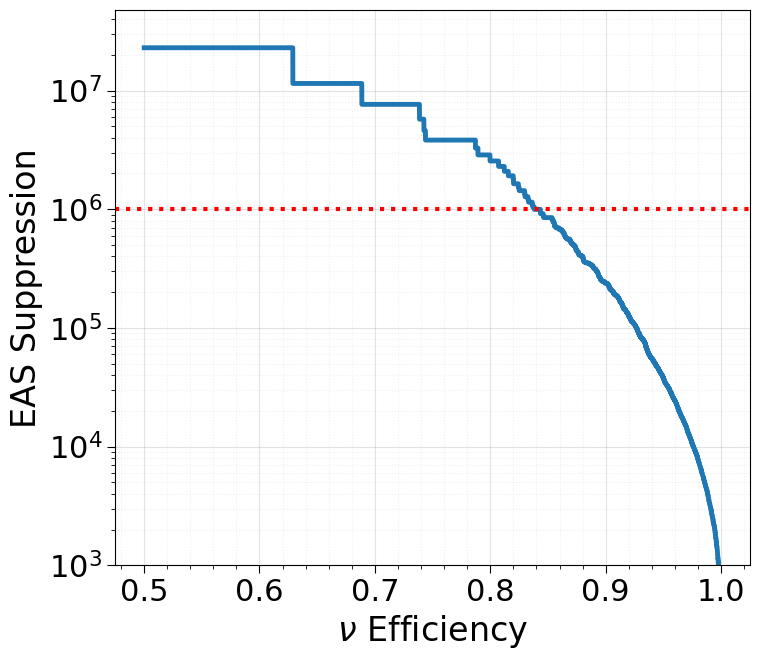

In [52]:
# ── Config ──
REF_H          = 8
REF_S          = 3
SUPP_CLIP      = 1e8
REF_FPR_TARGET = 1e6
CUT_LABEL      = f"Signal hits≥{REF_H}, Signal strings≥{REF_S}"

def make_quality_mask(h: int, s: int) -> np.ndarray:
    if h == 0:
        return np.ones(len(df_mc), dtype=bool)
    return (SIG_HITS >= h) & (SIG_S >= s)


def balanced_nuatm_nue2_subsample(pos_nuatm, pos_nue2, quality: np.ndarray,
                                   seed: int = 42) -> np.ndarray:
    """Subsample nuatm and nue2 to equal counts after quality cut."""
    rng = np.random.default_rng(seed)
    idx_nuatm = np.where(pos_nuatm & quality)[0]
    idx_nue2  = np.where(pos_nue2  & quality)[0]
    n = min(len(idx_nuatm), len(idx_nue2))
    sel_nuatm = rng.choice(idx_nuatm, size=n, replace=False)
    sel_nue2  = rng.choice(idx_nue2,  size=n, replace=False)
    mask = np.zeros(len(ptypes_arr), dtype=bool)
    mask[sel_nuatm] = True
    mask[sel_nue2]  = True
    return mask


def get_ref_point(pos_mask: np.ndarray):
    """Return (tpr, suppression, threshold) at TPR ~ REF_FPR_TARGET."""
    quality = make_quality_mask(REF_H, REF_S)
    keep    = (pos_mask & quality) | (IS_MU & quality)
    y_true  = pos_mask[keep].astype(int)
    y_score = SCORES[keep]
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    thr_arr = thr_arr[1:][::-1]
    tpr_arr = tpr_arr[1:][::-1]
    fpr_arr = fpr_arr[1:][::-1]
    inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
    idx = min(np.searchsorted(inv_fpr, REF_FPR_TARGET), len(thr_arr) - 1)
    return float(tpr_arr[idx]), float(inv_fpr[idx]), float(thr_arr[idx])


# # ── Build sample ──
# quality         = make_quality_mask(REF_H, REF_S)
# pos_nu_balanced = balanced_nuatm_nue2_subsample(pos_nuatm, pos_nue2, quality)
# keep            = (IS_NU & pos_nu_balanced & quality) | (IS_MU & quality)

# y_true  = (IS_NU & pos_nu_balanced)[keep].astype(int)
# y_score = SCORES[keep]

# # Event counts after cuts (for title)
# n_mu_cut    = int(IS_MU[keep].sum())
# n_nuatm_cut = int((pos_nuatm & pos_nu_balanced)[keep].sum())
# n_nue2_cut  = int((pos_nue2  & pos_nu_balanced)[keep].sum())

# N_bg  = n_mu_cut
# N_sig = n_nuatm_cut + n_nue2_cut

# # ── ROC ──
# fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
# thr_arr = thr_arr[1:][::-1]
# tpr_arr = tpr_arr[1:][::-1]
# fpr_arr = fpr_arr[1:][::-1]
# inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), 10, SUPP_CLIP)
# clip    = (thr_arr >= 0) & (thr_arr <= 1) & (tpr_arr >= 0.5)

# # ── Reference point ──
# ref_tpr, ref_supp, ref_thr = get_ref_point(IS_NU & pos_nu_balanced)

# ── Plot ──
RC_PARAMS = {
    "font.size": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
}
with plt.rc_context(RC_PARAMS):
    fig, ax = plt.subplots(figsize=(8, 7))
    c = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]
    ax.plot(tpr_arr[clip], inv_fpr[clip], color=c,
            lw=3.5, 
            label=CUT_LABEL)

    ax.axhline(REF_FPR_TARGET, color="red", ls=":", lw=3,
            label=fr"EAS Suppression = {int(REF_FPR_TARGET)}")
    # ax.scatter([ref_tpr], [ref_supp], color="red", zorder=5, s=35)
    # ax.annotate(
    #     f"EAS Suppression = {REF_FPR_TARGET:,.0f}\n"
    #     fr"@ $\nu$ Efficiency = {int(ref_tpr*100)}%"
    #     #fr"@ $\xi$ = {ref_thr:.3f}"
    #     ,
    #     xy=(ref_tpr, ref_supp),
    #     xytext=(ref_tpr - 0.25, ref_supp-800000),
    #     #fontsize=10,
    #     color="black", fontstyle="italic",
    #     arrowprops=dict(arrowstyle="->", color="red", lw=2.5), va="center",
    # )

    ax.set_yscale("log")
    #ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(r"$\nu$ Efficiency")
    ax.set_ylabel(r"EAS Suppression")
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)

    fig.tight_layout()
    plt.ylim(bottom=1000)
    plt.show()

fig.savefig(f"nuclassifier_eff_supp_{MODEL_TAG}.png")

In [37]:
print(ref_thr)

0.990429699420929


## Cell 4 — UMAP of encoder representations

Samples ~10k events per domain, reloads their filtered hits from source h5,
encodes them with `model.get_feature_representation()`, then runs UMAP.

In [12]:
from inference.nu_classifier_model.utils import load_model, predict_scores

dev = "cuda:2" if torch.cuda.is_available() else "cpu"
model, norm_config, train_config = load_model(str(CHECKPOINT), device=dev)
model.eval()
with_probs = train_config.get("model", {}).get("input_dim", 5) == 6
print(f"Model loaded on {dev}, with_probs={with_probs}")

Model loaded on cuda:2, with_probs=False


In [13]:
@torch.no_grad()
def _encode_features_list(
    features_list, norm_config, model, device, batch_size=256, feats_with_probs=False
) -> np.ndarray:
    """Run model.get_feature_representation() on a list of hit arrays.
    Returns (N, d_model) float32 array."""
    if feats_with_probs:
        nrm = {
            "means": norm_config["means"] + [0.75],
            "stds":  norm_config["stds"]  + [0.25],
        }
        n_feat = 6
    else:
        nrm    = norm_config
        n_feat = 5

    means = torch.tensor(nrm["means"], dtype=torch.float32, device=device)
    stds  = torch.tensor(nrm["stds"],  dtype=torch.float32, device=device)

    all_enc = []
    n = len(features_list)
    for start in tqdm(range(0, n, batch_size), desc='Encoding features'):
        batch = features_list[start:start + batch_size]
        b = len(batch)
        lengths = [min(len(f), 500) for f in batch]
        max_len = max(lengths)
        lengths_t = torch.tensor(lengths, dtype=torch.long, device=device)

        padded = torch.zeros(b, max_len, n_feat, dtype=torch.float32, device=device)
        for i, feat in enumerate(batch):
            sl = lengths[i]
            padded[i, :sl] = torch.from_numpy(feat[:sl].astype(np.float32)).to(device)

        mask = torch.arange(max_len, device=device)[None, :] < lengths_t[:, None]
        padded = torch.where(mask.unsqueeze(-1), (padded - means) / (stds + 1e-8), padded)

        enc = model.get_feature_representation({"features": padded, "lengths": lengths_t, "mask": mask})
        all_enc.append(enc.cpu().numpy())

    return np.concatenate(all_enc, axis=0)


def _load_mc_enc_feats(
    mc_preds_h5, mc_h5_path, probs_h5_path,
    ptype, threshold, model, norm_config, with_probs, device,
    n_sample=10_000, batch_size=256, seed=42,
) -> np.ndarray:
    """Sample n_sample events, load their filtered hits (prob > threshold), encode."""
    from collections import defaultdict
    rng = np.random.RandomState(seed)

    locations = []
    with h5py.File(mc_preds_h5, "r") as f:
        grp = f["baikal_mc_merged"][ptype]
        parts = list(grp["event_ids"].keys())
        parts_sel = rng.choice(len(parts), 10, replace=False)
        parts = [parts[i] for i in parts_sel.tolist()]
        for pk in parts:
            eids = grp[f"event_ids/{pk}/data"][:]
            locations.extend([(pk, int(e)) for e in eids])

    if len(locations) > n_sample:
        idx = rng.choice(len(locations), n_sample, replace=False)
        locations = [locations[i] for i in idx]

    # Only parts that have sampled events — not all 10k parts
    pk_groups = defaultdict(list)
    for pk, eid in locations:
        pk_groups[pk].append(eid)

    features_list = []
    with h5py.File(mc_h5_path, "r") as mh, h5py.File(probs_h5_path, "r") as ph:
        for pk, eids in tqdm(pk_groups.items(), desc=f"Loading {ptype}"):
            data_raw  = mh[f"{ptype}/raw/data/{pk}/data"].astype(np.float32)
            ev_starts = mh[f"{ptype}/raw/ev_starts/{pk}/data"].astype(np.int64)
            probs     = ph[f"{ptype}/probs/{pk}/data"]
            for eid in eids:
                s, e = int(ev_starts[eid]), int(ev_starts[eid + 1])
                sig = probs[s:e] > threshold
                feats = data_raw[s:e][sig]
                if with_probs:
                    feats = np.column_stack([feats, probs[s:e][sig]])
                features_list.append(feats)

    print(f"  {ptype}: encoding {len(features_list)} events from {len(pk_groups)} parts")
    return _encode_features_list(features_list, norm_config, model, device,
                                  batch_size=batch_size, feats_with_probs=with_probs)


def _load_exp_enc_feats(
    exp_preds_h5, exp_h5_path,
    threshold, model, norm_config, with_probs, device,
    n_sample=10_000, batch_size=256, seed=42,
) -> np.ndarray:
    """Sample n_sample exp events, run sig-noise only on sampled parts, encode."""
    from collections import defaultdict
    from gplotnikov_sig_noise_models.k_nsol_labelneq0_da_hs128_k0p0001.sig_noise_model_v3 import (
        load_model as load_snmodel, predict_flat,
    )
    sn_model, _, sn_dev = load_snmodel(device="auto")

    rng = np.random.RandomState(seed)
    locations = []
    with h5py.File(exp_preds_h5, "r") as f:
        grp = f[EXP_KEY]
        parts = list(grp["event_ids"].keys())
        if 100<len(parts):
            parts_sel = rng.choice(len(parts), min(100, len(parts)), replace=False)
            parts = [parts[i] for i in parts_sel.tolist()]
        for pk in parts:
            eids = grp[f"event_ids/{pk}/data"][:]
            locations.extend([(pk, int(e)) for e in eids])
    print(len(locations))
    if len(locations) > n_sample:
        idx = rng.choice(len(locations), n_sample, replace=False)
        locations = [locations[i] for i in idx]

    # Only parts that have sampled events — exp has 28 parts so not a concern,
    # but kept consistent with MC version
    pk_groups = defaultdict(list)
    for pk, eid in locations:
        pk_groups[pk].append(eid)

    features_list = []
    with h5py.File(exp_h5_path, "r") as src:
        src_key = "exp_reco" if "exp_reco" in src else "exp"
        raw = src[src_key]["raw"]
        for pk, eids in tqdm(pk_groups.items(), desc="Loading exp"):
            data_raw  = raw[f"data/{pk}/data"][:].astype(np.float32)
            ev_starts = raw[f"ev_starts/{pk}/data"][:].astype(np.int64)
            probs = predict_flat(sn_model, data_raw, ev_starts,
                                  batch_size=batch_size, device=sn_dev, normalize=True)
            for eid in eids:
                s, e = int(ev_starts[eid]), int(ev_starts[eid + 1])
                sig = probs[s:e] > threshold
                feats = data_raw[s:e][sig]
                if with_probs:
                    feats = np.column_stack([feats, probs[s:e][sig]])
                features_list.append(feats)

    print(f"  exp: encoding {len(features_list)} events from {len(pk_groups)} parts")
    return _encode_features_list(features_list, norm_config, model, device,
                                  batch_size=batch_size, feats_with_probs=with_probs), locations


In [14]:
N_UMAP = 10_000

print("Encoding muatm...")
enc_muatm = _load_mc_enc_feats(
    MC_PREDS_H5, MC_H5, PROBS_H5, "muatm_2020",
    THRESHOLD, model, norm_config, with_probs, dev, n_sample=N_UMAP
)
print("Encoding nuatm...")
enc_nuatm = _load_mc_enc_feats(
    MC_PREDS_H5, MC_H5, PROBS_H5, "nuatm_2020",
    THRESHOLD, model, norm_config, with_probs, dev, n_sample=N_UMAP
)
print("Encoding nue2...")
enc_nue2  = _load_mc_enc_feats(
    MC_PREDS_H5, MC_H5, PROBS_H5, "nue2_2020",
    THRESHOLD, model, norm_config, with_probs, dev, n_sample=N_UMAP
)
print("Encoding exp...")
enc_exp, locations  = _load_exp_enc_feats(
    EXP_PREDS_H5, EXP_H5,
    THRESHOLD, model, norm_config, with_probs, dev, n_sample=100_000
)
print(f"Encoder shapes: muatm={enc_muatm.shape}  nuatm={enc_nuatm.shape}  "
      f"nue2={enc_nue2.shape}  exp={enc_exp.shape}")

Encoding muatm...


Loading muatm_2020:   0%|          | 0/10 [00:00<?, ?it/s]

  muatm_2020: encoding 10000 events from 10 parts


Encoding features:   0%|          | 0/40 [00:00<?, ?it/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


...

/home/albert/Baikal2025/gplotnikov_sig_noise_models/k_nsol_labelneq0_da_hs128_k0p0001/model_simplified.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.enc = nn.TransformerEncoder(enc_layer, num_layers)


Loading exp:   0%|          | 0/26 [00:00<?, ?it/s]

  exp: encoding 38491 events from 26 parts


Encoding features:   0%|          | 0/151 [00:00<?, ?it/s]

Encoder shapes: muatm=(10000, 128)  nuatm=(10000, 128)  nue2=(10000, 128)  exp=(38491, 128)


In [15]:
strange_events = df_exp[EXP_MASK][['part_key', 'event_id']][df_exp[EXP_MASK]['score']>0.9]
strange_locations = strange_events.set_index(['part_key', 'event_id']).index.tolist()
strange_ids = []
for i, loc in enumerate(locations):
    if loc in strange_locations:
        strange_ids.append(i)

In [16]:
import umap


enc_exp_strange = enc_exp[strange_ids]
all_enc = np.vstack([enc_muatm, enc_nuatm, enc_nue2, enc_exp, enc_exp_strange])
labels_umap = np.array(
    ["muatm_2020"] * len(enc_muatm) +
    ["nuatm_2020"] * len(enc_nuatm) +
    ["nue2_2020"]  * len(enc_nue2)  +
    ["exp_reco"]   * len(enc_exp) + 
    ["exp_reco_strange"]   * len(enc_exp_strange)
)

print(f"Running UMAP on {len(all_enc):,} events...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(all_enc)
print("UMAP done.")

Running UMAP on 68,513 events...


/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


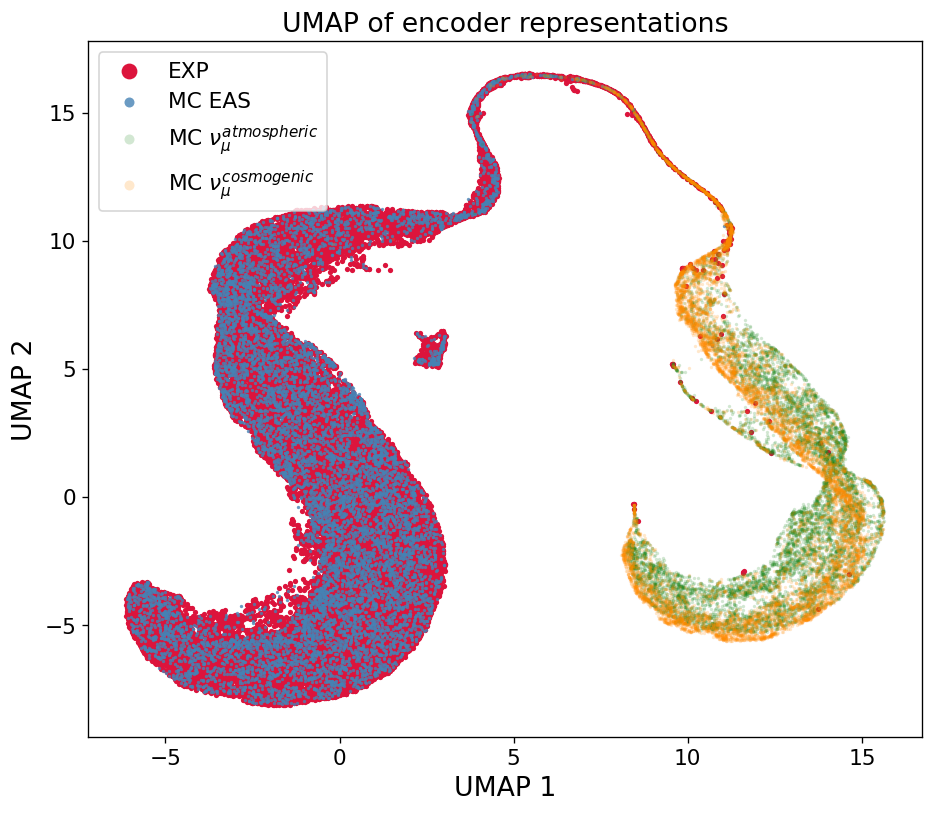

In [18]:
plt.close()
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(8, 7))
    order = ["exp_reco", "muatm_2020", "nuatm_2020", "nue2_2020", "exp_reco_strange"]
    alpha = {"exp_reco": 1.0, "muatm_2020": 0.8, "nuatm_2020": 0.2, "nue2_2020": 0.2, "exp_reco_strange": 1.0}
    size  = {"exp_reco": 10,    "muatm_2020": 4,    "nuatm_2020": 4,    "nue2_2020": 4, "exp_reco_strange": 50}
    for lbl in order[:4]:
        mask = labels_umap == lbl
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=PTYPE_COLORS[lbl], label=PTYPE_LABELS[lbl],
            s=size[lbl], alpha=alpha[lbl], linewidths=0,
        )
    ax.set_title(f"UMAP of encoder representations")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(markerscale=3)
    fig.tight_layout()
    plt.show()
fig.savefig(f"UMAP_raw_exp_{MODEL_TAG}.png")

## Cell 5 — MC metadata matching utility

Enrich MC predictions with truth info (energy, theta, …) from `baikal_mc_merged.h5`
by matching via `event_ids` stored in the predictions h5.

In [13]:
def load_baikal_mc_merged_metadata(
    scores_h5_path: str | Path,
    mc_h5_path: str | Path,
    extra_keys: list | None = None,
) -> pd.DataFrame:
    """Load MC prediction scores and optionally match fields from mc_h5 via event_ids.

    Args:
        scores_h5_path: Output of predict_mc.py.
        mc_h5_path:     baikal_mc_merged.h5 (source of raw events).
        extra_keys:     List of (h5_dataset_template, col_name) pairs.
                        Template placeholders: {ptype}, {pk}.
                        Example:
                            [('{ptype}/prime_prty/{pk}/data', 'prime_prty')]
                        The fetched array is indexed by event_ids (rows only).

    Returns:
        DataFrame: ptype, part_key, event_id, score, n_sig_hits, n_sig_strings
                   + any extra_keys columns.
    """
    chunks = []
    with h5py.File(scores_h5_path, "r") as sh, h5py.File(mc_h5_path, "r") as mh:
        mc_grp = sh["baikal_mc_merged"]
        for ptype in mc_grp.keys():
            if "scores" not in mc_grp[ptype]:
                continue
            for pk in tqdm(mc_grp[ptype]["scores"].keys()):
                scores    = mc_grp[f"{ptype}/scores/{pk}/data"][:]
                n_sh      = mc_grp[f"{ptype}/n_sig_hits/{pk}/data"][:]
                n_ss      = mc_grp[f"{ptype}/n_sig_strings/{pk}/data"][:]
                event_ids = mc_grp[f"{ptype}/event_ids/{pk}/data"][:]
                df_part = pd.DataFrame({
                    "ptype":         ptype,
                    "part_key":      pk,
                    "event_id":      event_ids,
                    "score":         scores,
                    "n_sig_hits":    n_sh,
                    "n_sig_strings": n_ss,
                })
                if extra_keys:
                    for template, col_name in extra_keys:
                        ds_path = template.format(ptype=ptype, pk=pk)
                        if ds_path in mh:
                            df_part[col_name] = list(mh[ds_path][:][event_ids])
                chunks.append(df_part)
    df = pd.concat(chunks, ignore_index=True)
    print(f"MC metadata loaded: {len(df):,} events")
    return df


df_mc_meta = load_baikal_mc_merged_metadata(
    MC_PREDS_H5, MC_H5,
    extra_keys=[("{ptype}/prime_prty/{pk}/data", "prime_prty")],
)
df_mc_meta["energy_mc"] = df_mc_meta["prime_prty"].apply(lambda x: x[2])
df_mc_meta["theta_mc"]  = df_mc_meta["prime_prty"].apply(lambda x: x[0])

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/67 [00:00<?, ?it/s]

MC metadata loaded: 76,560,464 events


In [14]:
df_mc_meta[MC_MASK]

,ptype,part_key,event_id,score,n_sig_hits,n_sig_strings,prime_prty,energy_mc,theta_mc
7,muatm_2020,part_10002,28,0.000567,15,3,"[137.57443, 202.9283, 839.6316, 5626.0, 15.0, ...",839.631592,137.574432
18,muatm_2020,part_10002,90,0.000475,10,3,"[151.02214, 344.2593, 165.48526, 402.0, 5.0, 1.0]",165.485260,151.022141
25,muatm_2020,part_10002,122,0.000860,16,5,"[113.47375, 108.19794, 1632.9568, 1608.0, 20.0...",1632.956787,113.473747
36,muatm_2020,part_10002,152,0.000622,11,3,"[128.8945, 47.269928, 219.82501, 14.0, 5.0, 1.0]",219.825012,128.894501
37,muatm_2020,part_10002,162,0.000492,10,5,"[140.1979, 147.83331, 74.339485, 14.0, 6.0, 1.0]",74.339485,140.197906
...,...,...,...,...,...,...,...,...,...
76560456,nue2_2020,part_4102,16751,0.993383,50,5,"[35.192368, 167.37158, 651872.44, 1.0, 1.0, 8....",651872.437500,35.192368
76560457,nue2_2020,part_4102,16756,0.991865,14,3,"[47.92755, 340.70764, 13718.062, 1.0, 1.0, 3.0...",13718.061523,47.927551
76560459,nue2_2020,part_4102,16758,0.933576,8,3,"[72.79391, 270.78342, 58032.29, 1.0, 1.0, 4.22...",58032.289062,72.793907
76560460,nue2_2020,part_4102,16759,0.992350,10,4,"[72.79391, 270.78342, 58032.29, 1.0, 1.0, 4.22...",58032.289062,72.793907


In [16]:
from scipy.stats import beta as beta_dist

df = df_mc_meta[MC_MASK]

# ── Suppression & Efficiency vs Energy at ref_thr ──
LOG10_E_BINS = np.linspace(0, 8, 33)
THETA_BINS = np.linspace(0, 90, 11)
theta_bin_centers  = 0.5 * (THETA_BINS[:-1] + THETA_BINS[1:])
en_bin_centers  = 0.5 * (LOG10_E_BINS[:-1] + LOG10_E_BINS[1:])
ENERGY   = df['energy_mc'].values
THETA = df['theta_mc'].values
#ENERGY   = df_mc['mu_ind_energy'].apply(lambda x: max(x)).values
LOG10_E  = np.log10(np.maximum(ENERGY, 1e-9))
PASSES   = df['score'] >= ref_thr
ptypes_arr = df["ptype"].values

nue2_mask  = (ptypes_arr == "nue2_2020")
nuatm_mask = (ptypes_arr == "nuatm_2020")
muatm_mask = (ptypes_arr == "muatm_2020")
nu_mask = (nue2_mask | nuatm_mask)

def _beta_iqr(n_pass, n_tot):
    n_fail = n_tot - n_pass
    a = n_pass + 0.5
    b = np.maximum(n_fail + 0.5, 0.5)
    return beta_dist.ppf(0.25, a, b), beta_dist.ppf(0.75, a, b)


def binned_suppression(mask, bins=LOG10_E_BINS, property=LOG10_E):
    E = property[mask]
    P = PASSES[mask]
    n_tot, _  = np.histogram(E, bins=bins)
    n_pass, _ = np.histogram(E[P], bins=bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        supp         = np.where(n_pass > 0, n_tot / n_pass, np.nan)
        acc_q25, acc_q75 = _beta_iqr(np.maximum(n_pass, 1), np.maximum(n_tot, 1))
        raw_lo       = 1.0 / np.maximum(acc_q75, 1e-9)
        raw_hi       = 1.0 / np.maximum(acc_q25, 1e-9)
        supp_lo      = np.where(n_pass > 0, np.minimum(raw_lo, supp), np.nan)
        supp_hi      = np.where(n_pass > 0, np.maximum(raw_hi, supp), np.nan)
    return supp, supp_lo, supp_hi, n_tot


def binned_efficiency(mask, bins=LOG10_E_BINS, property=LOG10_E):
    E = property[mask]
    P = PASSES[mask]
    n_tot, _  = np.histogram(E, bins=bins)
    n_pass, _ = np.histogram(E[P], bins=bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        eff     = np.where(n_tot > 0, n_pass / np.maximum(n_tot, 1), np.nan)
        q25, q75 = _beta_iqr(np.maximum(n_pass, 0), np.maximum(n_tot, 1))
        eff_lo  = np.where(n_tot > 0, np.minimum(q25, eff), np.nan)
        eff_hi  = np.where(n_tot > 0, np.maximum(q75, eff), np.nan)
    return eff, eff_lo, eff_hi, n_tot

supp,     supp_lo,  supp_hi,  n_mu    = binned_suppression(muatm_mask,    LOG10_E_BINS, LOG10_E)
eff_nu, elo_nu, ehi_nu, n_nu = binned_efficiency(nu_mask, LOG10_E_BINS, LOG10_E)
eff_nuatm, elo_nuatm, ehi_nuatm, n_nuatm = binned_efficiency(nuatm_mask, LOG10_E_BINS, LOG10_E)
eff_nue2, elo_nue2, ehi_nue2, n_nue2 = binned_efficiency(nue2_mask, LOG10_E_BINS, LOG10_E)

theta_supp,     theta_supp_lo,  theta_supp_hi,  theta_n_mu    = binned_suppression(muatm_mask,    THETA_BINS, THETA)
theta_eff_nu, theta_elo_nu, theta_ehi_nu, theta_n_nu = binned_efficiency(nu_mask, THETA_BINS, THETA)
theta_eff_nuatm, theta_elo_nuatm, theta_ehi_nuatm, theta_n_nuatm = binned_efficiency(nuatm_mask, THETA_BINS, THETA)
theta_eff_nue2, theta_elo_nue2, theta_ehi_nue2, theta_n_nue2 = binned_efficiency(nue2_mask, THETA_BINS, THETA)

# ── Shared x limits ──
valid_mu    = np.isfinite(supp)     & (n_mu    >= 5)
valid_nu  = np.isfinite(eff_nu) & (n_nu >= 5)
valid_nuatm  = np.isfinite(eff_nuatm) & (n_nuatm >= 5)
valid_nue2  = np.isfinite(eff_nue2) & (n_nue2 >= 5)
any_valid = valid_mu | valid_nu

th_valid_mu    = np.isfinite(theta_supp)     & (theta_n_mu    >= 5)
th_valid_nu  = np.isfinite(theta_eff_nu) & (theta_n_nu >= 5)
th_valid_nuatm  = np.isfinite(theta_eff_nuatm) & (theta_n_nuatm >= 5)
th_valid_nue2  = np.isfinite(theta_eff_nue2) & (theta_n_nue2 >= 5)
th_any_valid = th_valid_mu | th_valid_nu

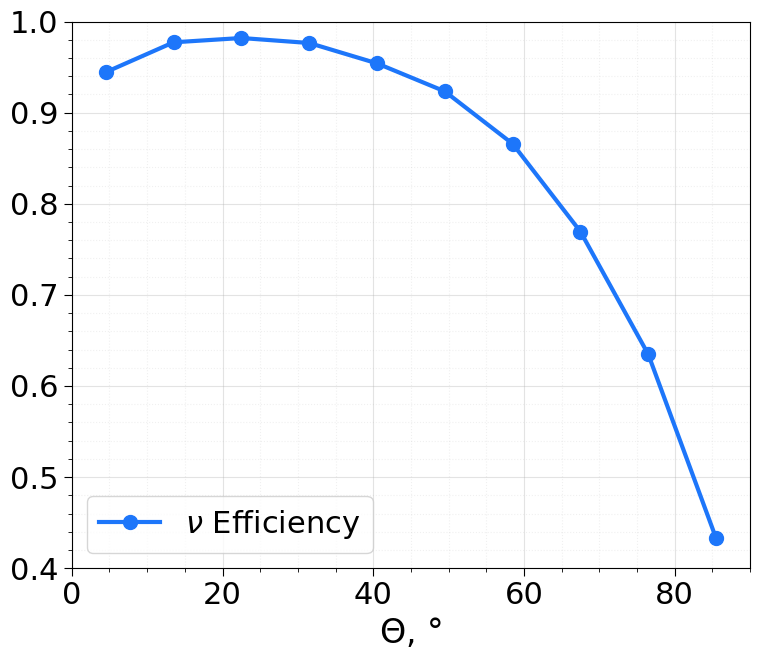

In [53]:
RC_PARAMS = {
    "font.size": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
}

with plt.rc_context(RC_PARAMS):
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 7), sharey=False)

    # -- Left: nu efficiency VS Theta --
    # ax1.fill_between(theta_bin_centers[valid_nuatm],
    #                 np.clip(theta_elo_nuatm[valid_nuatm], 0, 1),
    #                 np.clip(theta_ehi_nuatm[valid_nuatm], 0, 1),
    #                 alpha=0.2, color="#1D76FA")
    # ax1.fill_between(theta_bin_centers[valid_nue2],
    #                 np.clip(theta_elo_nue2[valid_nue2], 0, 1),
    #                 np.clip(theta_ehi_nue2[valid_nue2], 0, 1),
    #                 alpha=0.2, color="#3A0A5F")
    #ax1.plot(theta_bin_centers[valid_nu], eff_nu[valid_nu], color="#009E73", lw=2,
    #        marker="o", ms=6, label=r"$\nu_\mu$ Efficiency")
    # ax1.plot(theta_bin_centers[valid_nuatm], theta_eff_nuatm[valid_nuatm], color="#1D76FA", lw=2,
    #         marker="o", ms=6, label=r"Atmospheric $\nu_\mu$")
    # ax1.plot(theta_bin_centers[valid_nue2], theta_eff_nue2[valid_nue2], color="#3A0A5F", lw=2,
    #         marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
    ax1.plot(theta_bin_centers[th_valid_nu], theta_eff_nu[th_valid_nu], color="#1D76FA", lw=3,
            marker="o", ms=10, label=r"$\nu$ Efficiency")

    ax1.set_xlim(0, 90)
    ax1.set_xlabel(r"$\Theta$, $\degree$")
    #ax1.set_ylabel(r"$\nu$ Efficiency")
    #ax1.set_title(f"ν Efficiency vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
    #ax1.set_ylim(0.5, 1.0)
    #ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
    #ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax1.legend(fontsize=22, loc=3)
    ax1.minorticks_on()
    ax1.grid(True, which="major", alpha=0.35)
    ax1.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax1.tick_params(which="major", length=6)
    ax1.tick_params(which="minor", length=3)
    ax1.set_ylim(0.4, 1.0)

    # ── Right: nu efficiency VS Energy──
    # ax2.fill_between(bin_centers[valid_nu],
    #                 np.clip(elo_nu[valid_nu], 0, 1),
    #                 np.clip(ehi_nu[valid_nu], 0, 1),
    #                 alpha=0.2, color="#009E73")
    # ax2.fill_between(en_bin_centers[valid_nuatm],
    #                 np.clip(elo_nuatm[valid_nuatm], 0, 1),
    #                 np.clip(ehi_nuatm[valid_nuatm], 0, 1),
    #                 alpha=0.2, color="#1D76FA")
    # ax2.fill_between(en_bin_centers[valid_nue2],
    #                 np.clip(elo_nue2[valid_nue2], 0, 1),
    #                 np.clip(ehi_nue2[valid_nue2], 0, 1),
    #                 alpha=0.2, color="#3A0A5F")
    #ax2.plot(en_bin_centers[valid_nu], eff_nu[valid_nu], color="#009E73", lw=2,
    #        marker="o", ms=6, label=r"$\nu_\mu$ Efficiency")
    # ax2.plot(en_bin_centers[valid_nuatm], eff_nuatm[valid_nuatm], color="#1D76FA", lw=2,
    #         marker="o", ms=6, label=r"Atmospheric $\nu_\mu$")
    # ax2.plot(en_bin_centers[valid_nue2], eff_nue2[valid_nue2], color="#3A0A5F", lw=2,
    #         marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
    # ax2.plot(en_bin_centers[valid_mu], 1. - 1/supp[valid_mu], color="#C86815", lw=2,
    #          marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
#     ax2.plot(en_bin_centers[valid_nu], eff_nu[valid_nu], color="#1D76FA", lw=2,
#             marker="o", ms=6, label=r"$\nu$ Efficiency")

#     #ax2.set_xlim(x_lim)
#     ax2.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
#     #ax2.set_ylabel(r"$\nu$ Efficiency")
#     #ax2.set_title(f"ν Efficiency vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
#     #ax2.set_ylim(0.5, 1.0)
#     #ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
#     #ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
#     ax2.legend(fontsize=20, loc=3)
#     ax2.minorticks_on()
#     ax2.grid(True, which="major", alpha=0.35)
#     ax2.grid(True, which="minor", alpha=0.18, linestyle=":")
#     ax2.tick_params(which="major", length=6)
#     ax2.tick_params(which="minor", length=3)

    #ax2.set_ylim(0.4, 1.0)
    fig.tight_layout()
    plt.show()
fig.savefig(f"./nu_classifier_eff_theta_nuall_{MODEL_TAG}.png")

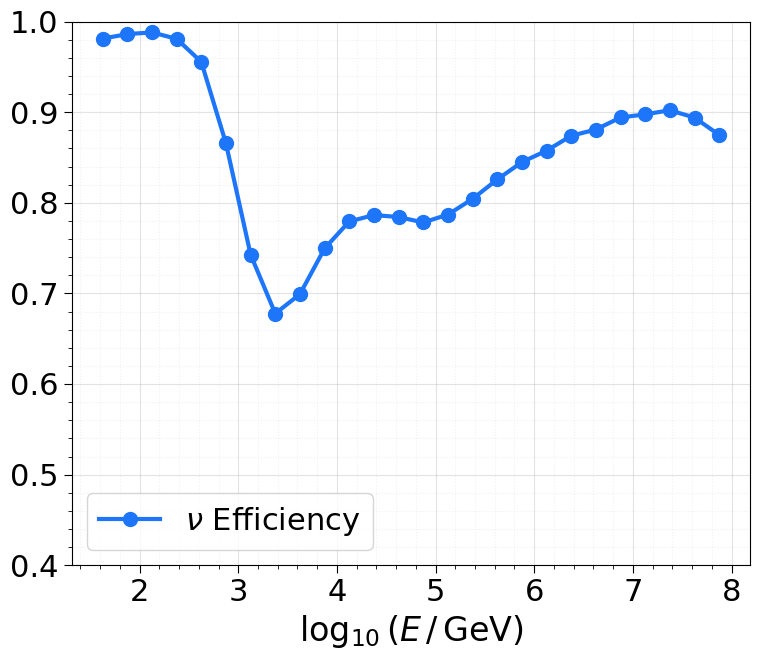

In [54]:
with plt.rc_context(RC_PARAMS):
    fig, ax2 = plt.subplots(1, 1, figsize=(8, 7), sharey=False)

    # -- Left: nu efficiency VS Theta --
    # ax1.fill_between(theta_bin_centers[valid_nuatm],
    #                 np.clip(theta_elo_nuatm[valid_nuatm], 0, 1),
    #                 np.clip(theta_ehi_nuatm[valid_nuatm], 0, 1),
    #                 alpha=0.2, color="#1D76FA")
    # ax1.fill_between(theta_bin_centers[valid_nue2],
    #                 np.clip(theta_elo_nue2[valid_nue2], 0, 1),
    #                 np.clip(theta_ehi_nue2[valid_nue2], 0, 1),
    #                 alpha=0.2, color="#3A0A5F")
    #ax1.plot(theta_bin_centers[valid_nu], eff_nu[valid_nu], color="#009E73", lw=2,
    #        marker="o", ms=6, label=r"$\nu_\mu$ Efficiency")
    # ax1.plot(theta_bin_centers[valid_nuatm], theta_eff_nuatm[valid_nuatm], color="#1D76FA", lw=2,
    #         marker="o", ms=6, label=r"Atmospheric $\nu_\mu$")
    # ax1.plot(theta_bin_centers[valid_nue2], theta_eff_nue2[valid_nue2], color="#3A0A5F", lw=2,
    #         marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
    # ax1.plot(theta_bin_centers[th_valid_nu], theta_eff_nu[th_valid_nu], color="#1D76FA", lw=2,
    #         marker="o", ms=6, label=r"$\nu$ Efficiency")

    # ax1.set_xlim(0, 90)
    # ax1.set_xlabel(r"$\Theta$, $\degree$")
    # #ax1.set_ylabel(r"$\nu$ Efficiency")
    # #ax1.set_title(f"ν Efficiency vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
    # #ax1.set_ylim(0.5, 1.0)
    # #ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
    # #ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
    # ax1.legend(fontsize=20, loc=3)
    # ax1.minorticks_on()
    # ax1.grid(True, which="major", alpha=0.35)
    # ax1.grid(True, which="minor", alpha=0.18, linestyle=":")
    # ax1.tick_params(which="major", length=6)
    # ax1.tick_params(which="minor", length=3)
    # ax1.set_ylim(0.4, 1.0)

    # # ── Right: nu efficiency VS Energy──
    # ax2.fill_between(bin_centers[valid_nu],
    #                 np.clip(elo_nu[valid_nu], 0, 1),
    #                 np.clip(ehi_nu[valid_nu], 0, 1),
    #                 alpha=0.2, color="#009E73")
    # ax2.fill_between(en_bin_centers[valid_nuatm],
    #                 np.clip(elo_nuatm[valid_nuatm], 0, 1),
    #                 np.clip(ehi_nuatm[valid_nuatm], 0, 1),
    #                 alpha=0.2, color="#1D76FA")
    # ax2.fill_between(en_bin_centers[valid_nue2],
    #                 np.clip(elo_nue2[valid_nue2], 0, 1),
    #                 np.clip(ehi_nue2[valid_nue2], 0, 1),
    #                 alpha=0.2, color="#3A0A5F")
    #ax2.plot(en_bin_centers[valid_nu], eff_nu[valid_nu], color="#009E73", lw=2,
    #        marker="o", ms=6, label=r"$\nu_\mu$ Efficiency")
    # ax2.plot(en_bin_centers[valid_nuatm], eff_nuatm[valid_nuatm], color="#1D76FA", lw=2,
    #         marker="o", ms=6, label=r"Atmospheric $\nu_\mu$")
    # ax2.plot(en_bin_centers[valid_nue2], eff_nue2[valid_nue2], color="#3A0A5F", lw=2,
    #         marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
    # ax2.plot(en_bin_centers[valid_mu], 1. - 1/supp[valid_mu], color="#C86815", lw=2,
    #          marker="o", ms=6, label=r"Cosmogenic $\nu_\mu$")
    ax2.plot(en_bin_centers[valid_nu], eff_nu[valid_nu], color="#1D76FA", lw=3,
            marker="o", ms=10, label=r"$\nu$ Efficiency")

    #ax2.set_xlim(x_lim)
    ax2.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
    #ax2.set_ylabel(r"$\nu$ Efficiency")
    #ax2.set_title(f"ν Efficiency vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
    #ax2.set_ylim(0.5, 1.0)
    #ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
    #ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax2.legend(fontsize=22, loc=3)
    ax2.minorticks_on()
    ax2.grid(True, which="major", alpha=0.35)
    ax2.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax2.tick_params(which="major", length=6)
    ax2.tick_params(which="minor", length=3)

    ax2.set_ylim(0.4, 1.0)
    fig.tight_layout()
    plt.show()
fig.savefig(f"./nu_classifier_eff_energy_nuall_{MODEL_TAG}.png")

In [29]:
valid_nu

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [25]:
THETA_BINS

array([  0. ,   7.5,  15. ,  22.5,  30. ,  37.5,  45. ,  52.5,  60. ,
        67.5,  75. ,  82.5,  90. ,  97.5, 105. , 112.5, 120. , 127.5,
       135. , 142.5, 150. , 157.5, 165. , 172.5, 180. ])

In [45]:
with h5py.File(MC_H5, "r") as mh:
    print(mh['muatm_2020/ev_ids'].keys())
    print(mh['muatm_2020/muons_prty/aggregate/part_1000/data'][:10,-1])
    print(mh['nue2_2020/muons_prty'].keys())
    print(mh['nue2_2020/ev_ids/part_1000/data'].shape)

<KeysViewHDF5 ['part_1000', 'part_10000', 'part_10001', 'part_10002', 'part_10003', 'part_10004', 'part_10005', 'part_10006', 'part_10007', 'part_10008', 'part_10009', 'part_1001', 'part_10010', 'part_10011', 'part_10012', 'part_10013', 'part_10014', 'part_10015', 'part_10016', 'part_10017', 'part_10018', 'part_10019', 'part_1002', 'part_10020', 'part_10021', 'part_10022', 'part_10023', 'part_10024', 'part_10025', 'part_10026', 'part_10027', 'part_10028', 'part_10029', 'part_1003', 'part_10030', 'part_10031', 'part_10032', 'part_10033', 'part_10034', 'part_10035', 'part_10036', 'part_10037', 'part_10038', 'part_10039', 'part_1004', 'part_10040', 'part_10041', 'part_10042', 'part_10043', 'part_10044', 'part_10045', 'part_10046', 'part_10047', 'part_10048', 'part_10049', 'part_1005', 'part_10050', 'part_10051', 'part_10052', 'part_10053', 'part_10054', 'part_10055', 'part_10056', 'part_10057', 'part_10058', 'part_10059', 'part_1006', 'part_10060', 'part_10061', 'part_10062', 'part_10063'

In [51]:
with h5py.File(MC_H5, "r") as mh:
    print(mh['muatm_2020/clusters_centers/data'][:10])
    print(mh['muatm_2020/ev_ids/part_1000/data'][:10])
    print(mh['muatm_2020/muons_prty/aggregate/part_1000/data'][:10,-1])
    print(mh['nue2_2020/muons_prty'].keys())
    print(mh['nue2_2020/ev_ids/part_1000/data'].shape)

[[ 2.15385616e+02  1.16251927e+02  4.45793382e-01]
 [ 8.50812536e+00 -5.58244649e+00 -5.40172060e-04]
 [-4.56787589e+01  2.89528296e+02  1.11286316e+00]
 [ 2.90178993e+02 -1.07529820e+02 -1.47777268e+00]
 [ 6.12084984e+01 -3.01591814e+02 -1.25065785e+00]
 [-2.57740120e+02 -1.38016697e+02 -2.06323713e-02]
 [-2.71862360e+02  1.46940425e+02  1.18843507e+00]]
[b'muatm_1000_0' b'muatm_1000_1' b'muatm_1000_2' b'muatm_1000_3'
 b'muatm_1000_4' b'muatm_1000_5' b'muatm_1000_6' b'muatm_1000_7'
 b'muatm_1000_8' b'muatm_1000_9']
[1126.1425  1006.5066   468.93362  764.9638  1665.1611  1352.906
 1630.7396   332.899    283.13257 1468.8003 ]
<KeysViewHDF5 ['aggregate', 'individ', 'mu_starts']>
(23500,)
